# Testing for Stationarity (ADF Test)

C:\Users\mar_c\AppData\Local\Temp\ipykernel_36232\1581724548.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2018-01-01', end='2025-12-31')['Close']
[*********************100%***********************]  1 of 1 completed


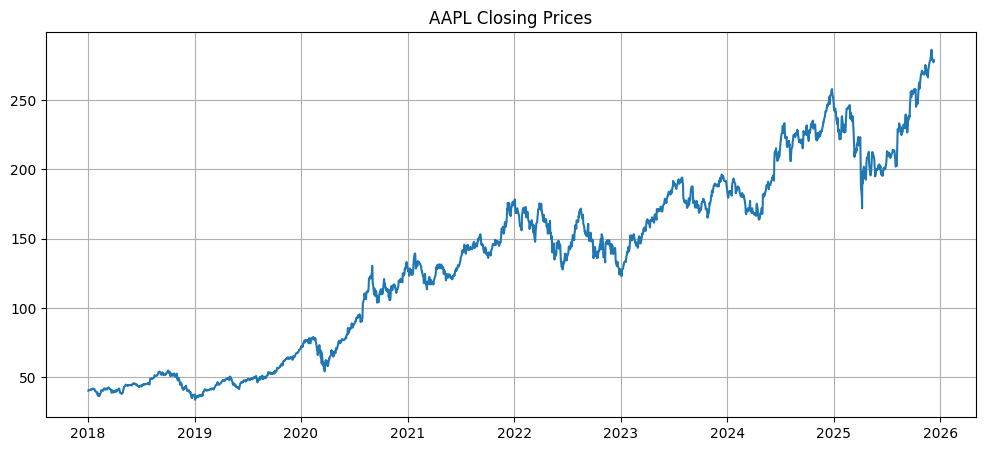

ADF Statistic: -0.11752039497697485
p-value: 0.9476652305040341


In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

data = yf.download('AAPL', start='2018-01-01', end='2025-12-31')['Close']

plt.figure(figsize=(12,5))
plt.plot(data)
plt.title("AAPL Closing Prices")
plt.grid(True)
plt.show()

adf_result = adfuller(data)
print(f"ADF Statistic: {adf_result[0]}") ##Comprueba la estacionariedad de la serie temporal si el valor es negativo y el p-value es menor a 0.05 entonces la serie es estacionaria
print(f"p-value: {adf_result[1]}") 


# Making a Series Stationary (Differencing)

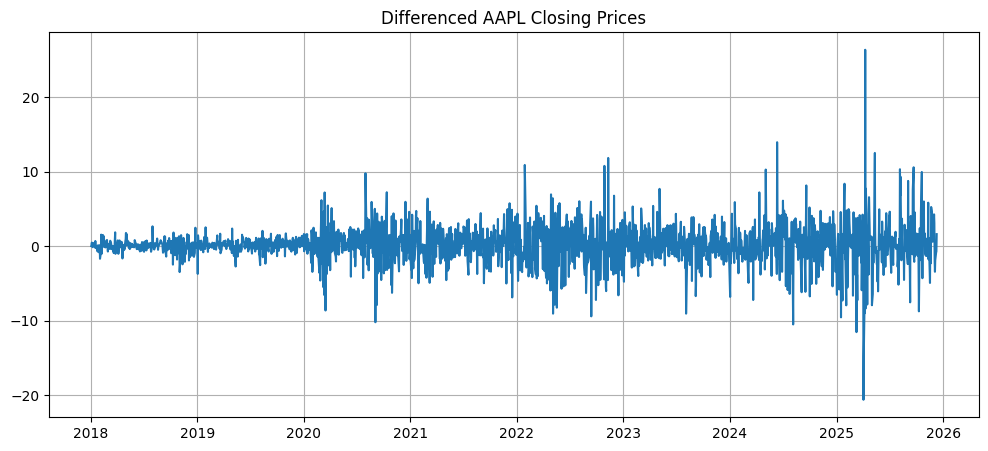

ADF Statistic (Differenced): -15.571718568241447
p-value (Differenced): 1.9828720799222284e-28


In [ ]:
##Aqui crea la serie estacionara al solo comar en cuenta la diferencia de precios entre dias consecutivos
data_diff = data.diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(data_diff)
plt.title("Differenced AAPL Closing Prices")
plt.grid(True)
plt.show()

adf_result_diff = adfuller(data_diff)
print(f"ADF Statistic (Differenced): {adf_result_diff[0]}")
print(f"p-value (Differenced): {adf_result_diff[1]}")


# Decomposing Time Series into Components

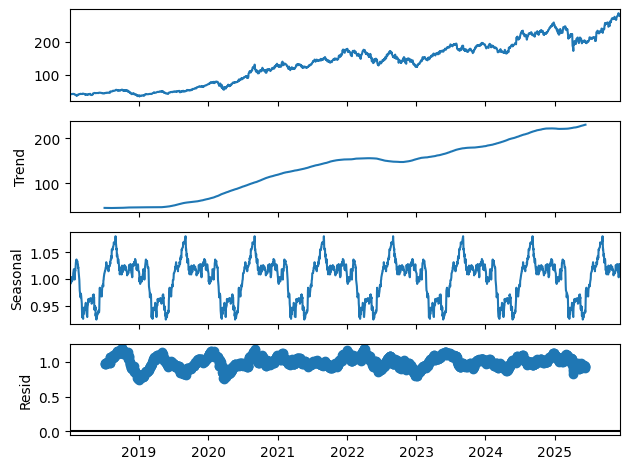

In [ ]:
##Se debe usar sobre todo con los retornos logaritmicos para descomponer la serie temporal en sus componentes: tendencia, estacionalidad y residuo.
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(data, model='multiplicative', period=252)  # ~1 year of trading days
result.plot()
plt.tight_layout()
plt.show()

# El Trend muestra la dirección general a largo plazo de los datos borrando las fluctuaciones estacionales y de ruido.
# La Seasonal muestra los patrones que se repiten en intervalos regulares de tiempo, un vallor en 0.95 representa que en ese periodo el valor es un 5% menor al promedio anual y viceversa
# El Residual muestra lo que queda después de eliminar el Trend y la Seasonal, representando el ruido o las fluctuaciones aleatorias en los datos donde si un dia el valor es 1.10 representa que el valor es un 10% mayor al valor esperado en ese periodo.

# Rolling Mean and Variance Diagnostics

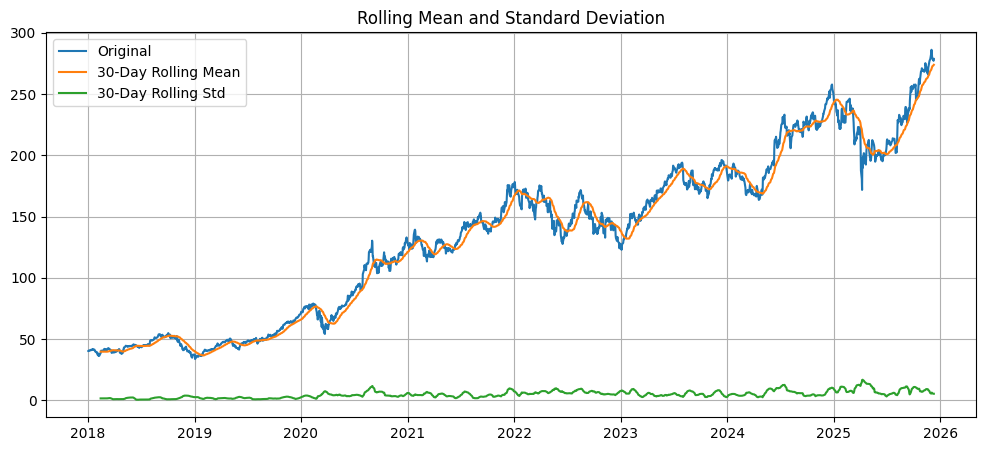

In [10]:
rolling_mean = data.rolling(window=30).mean()
rolling_std = data.rolling(window=30).std()

plt.figure(figsize=(12,5))
plt.plot(data, label='Original')
plt.plot(rolling_mean, label='30-Day Rolling Mean')
plt.plot(rolling_std, label='30-Day Rolling Std')
plt.legend()
plt.title('Rolling Mean and Standard Deviation')
plt.grid(True)
plt.show()


# Log-Transformation & Volatility Stationarity

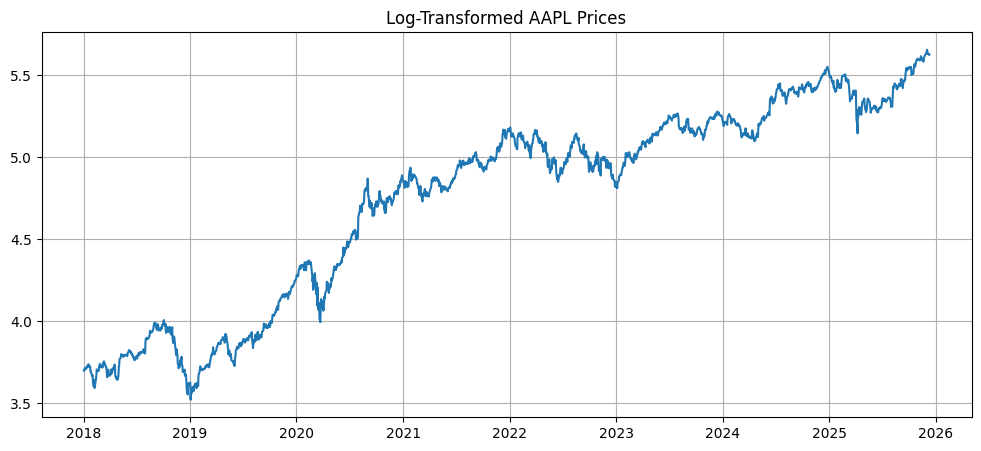

ADF Statistic (Log Prices): -0.9732879343048941
p-value (Log Prices): 0.7628818289493512


In [6]:
import numpy as np

# Log transformation of prices
log_data = np.log(data)

plt.figure(figsize=(12,5))
plt.plot(log_data)
plt.title("Log-Transformed AAPL Prices")
plt.grid(True)
plt.show()

# ADF Test on Log-Transformed Data
adf_result_log = adfuller(log_data.dropna())
print(f"ADF Statistic (Log Prices): {adf_result_log[0]}")
print(f"p-value (Log Prices): {adf_result_log[1]}")


# Volatility Stationarity Check (for GARCH models)

In [ ]:
##Aqui se comprueba que la volatilidad es estacionaria
# Squared returns (proxy for volatility)
squared_returns = data_diff ** 2

# ADF Test on squared returns
adf_result_vol = adfuller(squared_returns.dropna())
print(f"ADF Statistic (Squared Returns): {adf_result_vol[0]}")
print(f"p-value (Squared Returns): {adf_result_vol[1]}")


ADF Statistic (Squared Returns): -6.185751129837482
p-value (Squared Returns): 6.29561513095563e-08
